# From MPC Orbit to Ephemeris-Quality Integration with ASSIST

#### This tutorial demonstrates how to take an orbit from the MPC's Orbits API and integrate it at ephemeris quality using ASSIST.

[ASSIST](https://assist.readthedocs.io/) is an extension of the [REBOUND](https://rebound.readthedocs.io/) N-body package for high-accuracy integrations of test particles in the Solar System. Instead of integrating the planets themselves, ASSIST reads their positions directly from the JPL DE440/441 development ephemerides and adds the forces used in JPL's own small-body propagation: the Sun, planets and Moon, the 16 most massive asteroids, general-relativistic corrections (EIH formulation), and the J2/J3/J4 harmonics of the Earth and Sun. This lets ASSIST reproduce JPL's small-body trajectories to roughly 10 m over decade timescales ([Holman et al. 2023](https://ui.adsabs.harvard.edu/abs/2023PSJ.....4...69H)).

We will:
1. Fetch the orbit of the main-belt asteroid (3666) Holman from the MPC Orbits API
2. Parse it with the `mpc_orb` Python package to access the Cartesian state vector
3. Download the JPL ephemeris files that ASSIST requires
4. Convert the MPC state vector into ASSIST's conventions (barycentric, equatorial)
5. Integrate for 20 years with ASSIST's full force model
6. Compare against a plain Newtonian REBOUND integration of the Sun + planets
7. Explore which individual forces in the ASSIST model matter most

We use (3666) Holman — the same asteroid used in ASSIST's own documentation examples, and named after the MPC's director.

Further information:
- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [mpc_orb Python package](https://github.com/Smithsonian/mpc-public/tree/main/mpc_orb)
- [ASSIST documentation](https://assist.readthedocs.io/)
- [REBOUND documentation](https://rebound.readthedocs.io/)


## Environment Setup

This notebook requires `rebound`, `assist`, `mpc-orb`, `astropy`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound assist mpc-orb astropy matplotlib numpy requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion Rebound tutorial, you only need to run `pip install assist` inside it.

**N.B. In Step 2 (below) a large ephemeris file needs to be downloaded, which may cause problems for users with slow connections**


# Install and Import Packages

We need `rebound` and `assist` for the integrations, `mpc-orb` for parsing MPC orbit data, and `astropy` for time conversions.


In [1]:
import os

import requests
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

import rebound
import assist
from mpc_orb.parse import MPCORB
from astropy.time import Time


# Step 1: Fetch and Parse the Orbit

We query the MPC Orbits API for (3666) Holman and parse the result with `mpc_orb`.

The `MPCORB` class provides structured access to orbital elements, uncertainties, covariance matrices, and metadata. Here we use the Cartesian (`CAR`) representation, which we can pass directly to an N-body integrator.


In [2]:
# Fetch the orbit of (3666) Holman from the MPC
object_name = "3666"
response = requests.get(
    "https://data.minorplanetcenter.net/api/get-orb",
    json={"desig": object_name}
)
response.raise_for_status()
mpc_orb_dict = response.json()[0]['mpc_orb'][0]

# Parse with mpc_orb
M = MPCORB(mpc_orb_dict)

# Display basic information
print("Object Designation Data:")
pprint(M.designation_data, indent=2, depth=2)
print()
print(f"Epoch (MJD): {M.epoch_data['epoch']}")
print(f"Time system: {M.epoch_data['timesystem']}")
print(f"Reference system: {M.system_data['refsys']} ({M.system_data['refframe']})")
print()

# Display Cartesian elements with uncertainties
print("Cartesian orbital elements (AU, AU/day):")
print(f"{'Name':<6} {'Value':>20} {'Uncertainty':>16}")
print("-" * 44)
for name, val, unc in zip(
    M.CAR.coefficient_names[:6],
    M.CAR.coefficient_values[:6],
    M.CAR.coefficient_uncertainties[:6]
):
    print(f"{name:<6} {val:>20.15f} {unc:>16.6e}")

# Keep the 6-component state vector (heliocentric, ecliptic, AU & AU/day)
state = np.array(M.CAR.coefficient_values[:6])


Object Designation Data:
{ 'citation': '(3666) Holman = 1979 HP<br><br>Named in honor of Matthew J. '
              'Holman (b. 1967), astronomer in the planetary sciences division '
              'at the Harvard-Smithsonian Center for Astrophysics.  He is '
              'particularly known for his long-term investigations on the '
              'stability of the outer solar system by means of the symplectic '
              'integrator he codeveloped, and he has studied the stability of '
              'planets around other stars.  Recently, he has also become an '
              'active observer of centaurs and transneptunian objects. ',
  'designation_count': 1,
  'iau_designation': '(3666)',
  'iau_name': '',
  'name': 'Holman',
  'new_style_packed_secondary_provisional_designations': [ 'J38W00000Q',
                                                           'J82V00001H',
                                                           'J84C00001B'],
  'orbfit_name': '3666',
  'packed_per

# Step 2: Download the JPL Ephemeris Files

ASSIST does not integrate the planets itself — it reads their positions from the JPL development ephemerides. Two data files are required:

| File | Contents | Size |
|------|----------|------|
| `de440.bsp` | DE440 planetary ephemeris (years 1550–2650, SPK format) | ≈120 MB |
| `sb441-n16.bsp` | DE441 ephemeris of the 16 most massive asteroids | ≈650 MB |

The planetary file is the standard [NAIF SPK kernel](https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/) for DE440. (Older ASSIST examples use the equivalent `linux_p1550p2650.440` file in JPL's legacy binary format; ASSIST accepts either, and the two give identical results.)

**Warning: these files total roughly 770 MB.** The cell below downloads them into a local `assist_ephem_data/` directory *only if they are not already present*, so the download happens just once. If you already have copies of these files, place them in (or symlink them into) `assist_ephem_data/` before running the cell. Delete the directory to reclaim the disk space when you are done.


In [3]:
# Directory in which the ephemeris files are cached
DATA_DIR = "assist_ephem_data"
os.makedirs(DATA_DIR, exist_ok=True)

EPHEM_URLS = {
    "de440.bsp":
        "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440.bsp",
    "sb441-n16.bsp":
        "https://ssd.jpl.nasa.gov/ftp/eph/small_bodies/asteroids_de441/sb441-n16.bsp",
}

def download_if_missing(filename, url):
    """Download url to DATA_DIR/filename unless it is already there."""
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        print(f"Found existing file: {path} ({os.path.getsize(path)/1e6:.0f} MB)")
        return path
    print(f"Downloading {url}")
    print(f"  -> {path}  (large file: this may take several minutes)")
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(path + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(path + ".part", path)
    print(f"  done ({os.path.getsize(path)/1e6:.0f} MB)")
    return path

planets_path = download_if_missing("de440.bsp", EPHEM_URLS["de440.bsp"])
asteroids_path = download_if_missing("sb441-n16.bsp",
                                     EPHEM_URLS["sb441-n16.bsp"])

# Load the ephemerides into ASSIST
ephem = assist.Ephem(planets_path, asteroids_path)
print(f"\nEphemerides loaded. Reference Julian Date: JD {ephem.jd_ref}")


Found existing file: assist_ephem_data/de440.bsp (120 MB)
Found existing file: assist_ephem_data/sb441-n16.bsp (646 MB)

Ephemerides loaded. Reference Julian Date: JD 2451545.0


# Step 3: Convert the MPC State Vector to ASSIST Conventions

The MPC and ASSIST use different conventions, so the state vector must be transformed before it can be handed to ASSIST:

| | MPC `CAR` elements | ASSIST |
|---|---|---|
| Origin | Heliocentric | Barycentric (Solar System barycenter) |
| Frame | Ecliptic (ICRF-aligned) | Equatorial (ICRF) |
| Units | AU, AU/day | AU, AU/day |
| Time | Epoch as MJD (TT) | TDB Julian Date, relative to `ephem.jd_ref` |

The conversion therefore has two parts:

1. **Rotate ecliptic → equatorial.** This is a rotation about the x-axis by the obliquity of the ecliptic, $\varepsilon$. The exact obliquity value used by the MPC orbit fit is stored in the JSON itself (`system_data['EclipticObliquityArcseconds']`, the IAU76/J2000 value of 84381.448 arcseconds):

$$x_{eq} = x, \qquad y_{eq} = y\cos\varepsilon - z\sin\varepsilon, \qquad z_{eq} = y\sin\varepsilon + z\cos\varepsilon$$

2. **Shift heliocentric → barycentric.** We add the Sun's barycentric state at the epoch, which ASSIST can supply directly from the JPL ephemeris via `ephem.get_particle("sun", t)`.

**Time scales:** the MPC epoch is quoted in TT, while ASSIST expects TDB. The two differ by less than 2 milliseconds, which is entirely negligible here, so we simply treat the epoch as TDB. ASSIST measures time in days relative to `ephem.jd_ref` (JD 2451545.0, i.e. J2000), so the integration start time is `t0 = epoch_jd - ephem.jd_ref`.


In [4]:
# Obliquity used by the MPC orbit fit (arcseconds -> radians)
eps = np.radians(float(M.system_data['EclipticObliquityArcseconds']) / 3600.0)

def ecliptic_to_equatorial(v, eps):
    """Rotate a 3-vector from ecliptic to equatorial coordinates."""
    x, y, z = v
    return np.array([x,
                     y * np.cos(eps) - z * np.sin(eps),
                     y * np.sin(eps) + z * np.cos(eps)])

def equatorial_to_ecliptic(v, eps):
    """Rotate a 3-vector from equatorial to ecliptic coordinates (inverse)."""
    x, y, z = v
    return np.array([x,
                     y * np.cos(eps) + z * np.sin(eps),
                     -y * np.sin(eps) + z * np.cos(eps)])

# ASSIST times are (TDB) Julian Dates relative to ephem.jd_ref
epoch_mjd = M.epoch_data['epoch']      # TT ~ TDB (difference < 2 ms)
jd = epoch_mjd + 2400000.5
t0 = jd - ephem.jd_ref
print(f"Epoch: MJD {epoch_mjd} = {Time(jd, format='jd', scale='tt').iso[:10]}")
print(f"ASSIST start time: t0 = {t0} days after JD {ephem.jd_ref}")

# Sun's barycentric equatorial state at the epoch, from the JPL ephemeris
sun_t0 = ephem.get_particle("sun", t0)

# Heliocentric-ecliptic -> barycentric-equatorial
pos_bary_eq = ecliptic_to_equatorial(state[:3], eps) \
    + np.array([sun_t0.x, sun_t0.y, sun_t0.z])
vel_bary_eq = ecliptic_to_equatorial(state[3:], eps) \
    + np.array([sun_t0.vx, sun_t0.vy, sun_t0.vz])

print("\nBarycentric equatorial initial conditions for ASSIST:")
print(f"  position (AU):     {pos_bary_eq}")
print(f"  velocity (AU/day): {vel_bary_eq}")


Epoch: MJD 61200.0 = 2026-06-09
ASSIST start time: t0 = 9655.5 days after JD 2451545.0

Barycentric equatorial initial conditions for ASSIST:
  position (AU):     [2.93098533 1.653123   0.56316633]
  velocity (AU/day): [-0.00516135  0.00657297  0.00288736]


# Step 4: Integrate with ASSIST

We create a REBOUND simulation containing a single particle — the asteroid — and attach ASSIST to it with `assist.Extras`. ASSIST supplies all the forces (planets, massive asteroids, general relativity, harmonics) from the ephemeris files, and the integration uses REBOUND's adaptive high-order IAS15 integrator.

Two details to note:
- The simulation time `sim.t` must be set to `t0` **before** attaching `assist.Extras`, and all subsequent `sim.integrate(t)` calls use absolute times relative to `ephem.jd_ref`.
- The simulation state is barycentric-equatorial throughout. At each output time we subtract the Sun's ephemeris position and rotate back to the ecliptic frame, so that the stored positions are directly comparable with other heliocentric-ecliptic data.

We integrate for 20 years, recording the heliocentric position at 201 evenly-spaced output times.


In [5]:
# Create the REBOUND simulation and attach ASSIST
sim_assist = rebound.Simulation()
sim_assist.add(x=pos_bary_eq[0], y=pos_bary_eq[1], z=pos_bary_eq[2],
               vx=vel_bary_eq[0], vy=vel_bary_eq[1], vz=vel_bary_eq[2])
sim_assist.t = t0                      # set BEFORE attaching assist.Extras
ex = assist.Extras(sim_assist, ephem)

print("ASSIST force model:", ex.forces)
print(f"Integrator: {sim_assist.integrator}")

# Output times: 20 years, 201 evenly-spaced samples
n_years = 20.0
n_outputs = 201
times = t0 + np.linspace(0.0, n_years * 365.25, n_outputs)
times_yr = (times - t0) / 365.25

# Integrate, storing heliocentric-ecliptic positions at each output time
assist_helio_ecl = np.zeros((n_outputs, 3))
for k, t in enumerate(times):
    sim_assist.integrate(t)
    p = sim_assist.particles[0]
    sun = ephem.get_particle("sun", t)
    helio_eq = np.array([p.x - sun.x, p.y - sun.y, p.z - sun.z])
    assist_helio_ecl[k] = equatorial_to_ecliptic(helio_eq, eps)

print(f"\nIntegrated {n_years:.0f} years with {n_outputs} outputs.")
print(f"Final heliocentric distance: {np.linalg.norm(assist_helio_ecl[-1]):.4f} AU")


ASSIST force model: ['SUN', 'PLANETS', 'ASTEROIDS', 'NON_GRAVITATIONAL', 'EARTH_HARMONICS', 'SUN_HARMONICS', 'GR_EIH']
Integrator: ias15

Integrated 20 years with 201 outputs.
Final heliocentric distance: 3.2242 AU


# Step 5: The Same Orbit in Plain REBOUND

For comparison, we now integrate the *identical* initial state with a conventional REBOUND N-body setup: the Sun and eight planets loaded from JPL Horizons, interacting through Newtonian point-mass gravity only, again using the IAS15 integrator.

Relative to ASSIST, this model is missing the 16 massive asteroids, general-relativistic corrections, and the Earth/Sun oblateness harmonics — and the "Earth" particle loaded here is actually the Earth–Moon barycenter, so do **not** also add the Moon as a separate body.

**Unit and frame handling:** we set `sim.units = ('AU', 'day', 'Msun')` so REBOUND matches the MPC units. REBOUND's Horizons interface returns *barycentric* ecliptic coordinates, while the MPC state vector is *heliocentric* — so we add the asteroid's coordinates relative to the Sun particle.

Note that this repeats, in a different frame, the heliocentric-to-barycentric shift we performed for ASSIST in Step 3. That is deliberate: each simulation adds the asteroid relative to **its own** Sun, in **its own** frame, so each is self-consistent regardless of where its Sun state came from. (The two Sun states are in practice interchangeable — Horizons is built on the same JPL ephemerides that ASSIST reads, and at this epoch the two barycentric Sun positions agree to well below a metre — but keeping each simulation internally consistent is the habit that avoids subtle frame mix-ups.)

NB: It is possible that you may experience the following error when adding planets to rebound (which uses the NASA Horizons system to extract the planetary positions): `RuntimeError: An error occured while accessing NASA HORIZONS. If this is a SSL certificate issue, you can try disabling the certificate verification by setting rebound.horizons.SSL_CONTEXT = 'unverified'.`
 - In this scenario, the simplest approach is to just retry the evaluation, and this typically will succeed.


In [6]:
# Build a plain REBOUND simulation with the Sun and planets from JPL Horizons
epoch_date = f"JD{jd:.6f}"   # Horizons treats vector-query epochs as TDB
sim_nbody = rebound.Simulation()
sim_nbody.units = ('AU', 'day', 'Msun')

# NB: "Earth" resolves to the Earth-Moon barycenter -- do not also add "Moon"
bodies = ["Sun", "Mercury", "Venus", "Earth", "Mars",
          "Jupiter", "Saturn", "Uranus", "Neptune"]
for body in bodies:
    sim_nbody.add(body, date=epoch_date)
    print(f"Added {body}")

# Horizons-loaded particles are barycentric, the MPC state is heliocentric:
# add the asteroid relative to the Sun particle (ecliptic frame throughout)
sun_p = sim_nbody.particles[0]
sim_nbody.add(x=sun_p.x + state[0], y=sun_p.y + state[1], z=sun_p.z + state[2],
              vx=sun_p.vx + state[3], vy=sun_p.vy + state[4], vz=sun_p.vz + state[5])
print(f"Added ({object_name}) Holman as a test particle")

sim_nbody.integrator = "ias15"
sim_nbody.move_to_com()
i_ast = len(bodies)          # index of the asteroid particle

# Integrate to the same output times, storing heliocentric-ecliptic positions
rebound_helio_ecl = np.zeros((n_outputs, 3))
for k, t in enumerate(times):
    sim_nbody.integrate(t - t0)
    p = sim_nbody.particles[i_ast]
    s = sim_nbody.particles[0]
    rebound_helio_ecl[k] = [p.x - s.x, p.y - s.y, p.z - s.z]

print(f"\nFinal heliocentric distance: {np.linalg.norm(rebound_helio_ecl[-1]):.4f} AU")


Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Added Sun
Searching NASA Horizons for 'Mercury'... 


Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Added Mercury
Searching NASA Horizons for 'Venus'... 


Found: Venus Barycenter (299) (chosen from query 'Venus')
Added Venus
Searching NASA Horizons for 'Earth'... 


Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Added Earth
Searching NASA Horizons for 'Mars'... 


Found: Mars Barycenter (4) (chosen from query 'Mars')
Added Mars
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Added Jupiter
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Added Saturn
Searching NASA Horizons for 'Uranus'... 


Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Added Uranus
Searching NASA Horizons for 'Neptune'... 


Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Added Neptune
Added (3666) Holman as a test particle

Final heliocentric distance: 3.2242 AU


# Step 6: Compare REBOUND vs ASSIST

Both integrations started from exactly the same asteroid state vector, so any difference between them comes purely from the force models (and from small differences in how the planets are represented). We compute the distance between the two predicted heliocentric positions at each output time.

For a quiet main-belt orbit like (3666) Holman, the difference oscillates over the asteroid's 5.4-year orbital period while its envelope steadily grows: you should find approximately **4 km after 5 years, 8 km after 10 years, and 23 km after 20 years** at the sampled times, with oscillation peaks reaching several tens of km.


After   1.0 years: |REBOUND - ASSIST| =     2.23 km
After   5.0 years: |REBOUND - ASSIST| =     4.12 km
After  10.0 years: |REBOUND - ASSIST| =     7.79 km
After  20.0 years: |REBOUND - ASSIST| =    22.60 km


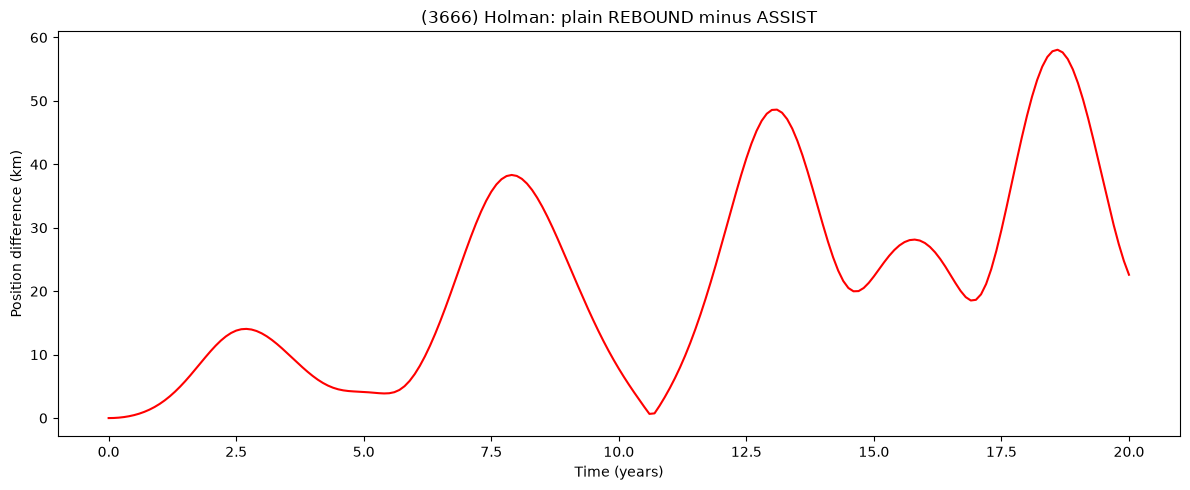

In [7]:
AU_KM = 149597870.7   # kilometres per AU

dr_km = np.linalg.norm(assist_helio_ecl - rebound_helio_ecl, axis=1) * AU_KM

for yr in [1, 5, 10, 20]:
    k = np.argmin(np.abs(times_yr - yr))
    print(f"After {times_yr[k]:5.1f} years: |REBOUND - ASSIST| = {dr_km[k]:8.2f} km")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times_yr, dr_km, color='red', linewidth=1.5)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Position difference (km)')
ax.set_title(f'({object_name}) Holman: plain REBOUND minus ASSIST')
plt.tight_layout()
plt.show()


### How accurate is this in absolute terms?

A few tens of km after 20 years is a tiny difference in orbital-dynamics terms (the asteroid travels about 3 AU per year), but it matters whenever ephemeris-quality predictions are needed: precise ephemerides for observations, occultation predictions, radar astrometry, close-approach analyses, and impact monitoring.

It is worth being clear about what limits the *absolute* accuracy here. If you compare the ASSIST trajectory for (3666) Holman against JPL Horizons, you will find a difference of roughly 65 km after 10 years. That difference is dominated by the fact that the MPC and JPL orbit *fits* for the asteroid differ slightly at the epoch — not by the propagation itself: ASSIST reproduces JPL's own propagation at the level of roughly 10 m per decade ([Holman et al. 2023](https://ui.adsabs.harvard.edu/abs/2023PSJ.....4...69H)). In other words, with ASSIST the force model is no longer the limiting factor; the orbit-fit uncertainty is.


# Step 7: Which Forces Matter?

ASSIST lets us switch individual force components on and off through the `forces` attribute of the `Extras` object. By re-running the 20-year integration with one force removed at a time and measuring how far the final position moves, we can see how much each component of the force model contributes for this orbit.


In [8]:
def final_position(forces_to_remove):
    """Re-run the 20-year ASSIST integration with some forces disabled;
    return the final barycentric position (AU)."""
    sim = rebound.Simulation()
    sim.add(x=pos_bary_eq[0], y=pos_bary_eq[1], z=pos_bary_eq[2],
            vx=vel_bary_eq[0], vy=vel_bary_eq[1], vz=vel_bary_eq[2])
    sim.t = t0
    ex = assist.Extras(sim, ephem)
    ex.forces = [f for f in ex.forces if f not in forces_to_remove]
    sim.integrate(times[-1])
    p = sim.particles[0]
    return np.array([p.x, p.y, p.z])

# Reference: the full force model
pos_full = final_position([])

print(f"Effect of removing each force on the final position ({n_years:.0f} years):\n")
for force in ["GR_EIH", "ASTEROIDS", "EARTH_HARMONICS", "SUN_HARMONICS"]:
    shift = np.linalg.norm(final_position([force]) - pos_full) * AU_KM
    print(f"  without {force:<16}: final position shifts by {shift:9.2f} km")


Effect of removing each force on the final position (20 years):

  without GR_EIH          : final position shifts by    134.20 km
  without ASTEROIDS       : final position shifts by     36.51 km
  without EARTH_HARMONICS : final position shifts by      0.00 km
  without SUN_HARMONICS   : final position shifts by      0.01 km


### Discussion

For this orbit you should find that removing general relativity (`GR_EIH`) shifts the 20-year prediction by roughly 130 km, and removing the 16 massive asteroids (`ASTEROIDS`) by roughly 40 km, while the Earth and Sun harmonics are negligible for a main-belt object.

Note that the individual contributions are *larger* than the 23 km net difference we measured between ASSIST and plain REBOUND in Step 6. This is not a contradiction: the various force-model effects (and the small differences in the planetary representation) partially cancel each other in the net comparison. The force-by-force experiment gives the honest size of each physical effect.


# Summary

In this tutorial we:

1. **Fetched** the orbit of (3666) Holman from the MPC Orbits API
2. **Parsed** it with the `mpc_orb` package to access the Cartesian state vector
3. **Downloaded** the JPL DE440 planetary ephemeris and the DE441 massive-asteroid ephemeris that ASSIST requires
4. **Converted** the MPC heliocentric-ecliptic state into ASSIST's barycentric-equatorial convention using the obliquity value stored in the orbit JSON
5. **Integrated** for 20 years with ASSIST's full, ephemeris-quality force model
6. **Compared** against a plain Newtonian REBOUND integration, finding differences growing to tens of km over 20 years
7. **Dissected** the force model, showing that general relativity and the massive asteroids are the dominant corrections for this orbit

Use plain REBOUND when you need to integrate many mutually-interacting bodies or explore long-term dynamics (as in the companion Rebound tutorial); use ASSIST when you need ephemeris-quality trajectories of individual small bodies over years-to-centuries timescales.

### Further Resources

- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [mpc_orb Python package](https://github.com/Smithsonian/mpc-public/tree/main/mpc_orb)
- [ASSIST documentation](https://assist.readthedocs.io/)
- [Holman et al. 2023 (ASSIST)](https://ui.adsabs.harvard.edu/abs/2023PSJ.....4...69H)
- [REBOUND documentation](https://rebound.readthedocs.io/)
- [Rein & Spiegel 2015 (IAS15)](https://ui.adsabs.harvard.edu/abs/2015MNRAS.446.1424R)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).
